# Population Parameters Vs Sample Statistics

A **population parameter** is a numerical value that summarises a characteristic of a population. For instance, the **average salary** of data scientists in Germany is a population parameter.

Some examples of population parameters include:
- **Population mean $\mu$**: The average value of a variable in the population.
- **Population standard deviation $\sigma$**: A measure of how much the values in the population deviate from the mean.

Conversely, a **sample statistic** describes a characteristic of a sample, drawn from the 
population. For example, the **average salary** of data scientists in a sample of 1000 data scientists from Germany is a sample statistic.

The table below summarises some of the most common population parameters and their corresponding sample statistics:

| Characteristic | Population Parameter | Sample Statistic |
|----------------|---------------------|-------------------|
| Mean           | $\mu$               | $\bar{x}$        |
| Standard Deviation | $\sigma$           | $s$           |
| Variance       | $\sigma^2$          | $s^2$            |
| Proportion     | $p$                 | $\hat{p}$         |

> **Recommended pre-reading for `ci_guide.ipynb`.** This notebook derives the standard error and the sampling distribution that confidence intervals are built on. Work through it before (or alongside) the confidence-intervals guide.

## Learning Objectives

At the end of this notebook, you should be able to:

- Distinguish a population parameter from a sample statistic.
- Explain how a sample statistic estimates a population parameter, and why a larger sample estimates it better.
- Describe the sampling distribution of the mean and compute its standard error, `σ/√n`.
- Apply the central limit theorem to explain the normal shape of that sampling distribution.


Let's suppose that the salary of data scientists in Germany is normally distributed with a mean of *65,000* euros and a standard deviation of *15,000* euros. 
These values are the **population parameters**.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scipy.stats as stats

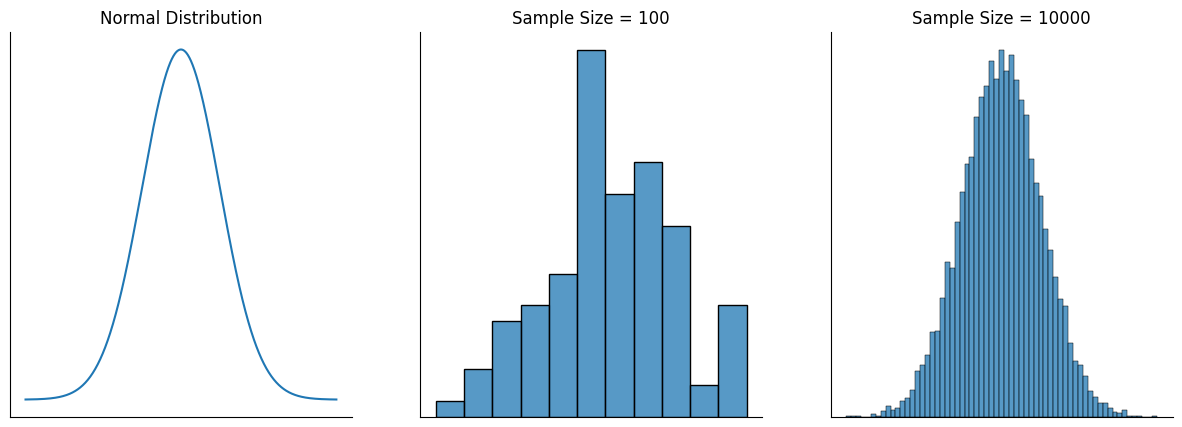

In [3]:
# Set the seed for reproducibility
np.random.seed(42)

# Le'ts create a greed of three subplots
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))

# Create a normal distribution
# Population parameters (mean and standard deviation)
mu = 65_000
sigma = 15_000

# Define a range of x values
x = np.linspace(mu - 4 * sigma, mu + 4 * sigma, 1000)
# Calculate the probability density function (PDF)
y = stats.norm.pdf(loc=mu, scale=sigma, x=x)
# Plot the normal distribution
ax0 = sns.lineplot(x=x, y=y, ax=axes[0])

# Draw 100 samples from the normal distribution
n_samples = 100
Salaries_100 = np.random.normal(loc=mu, scale=sigma, size=n_samples)
# Plot the histogram of the samples
ax1 = sns.histplot(Salaries_100, ax=axes[1])

# Draw 10000 samples from the normal distribution
n_samples = 10000
Salaries_10000 = np.random.normal(loc=mu, scale=sigma, size=n_samples)
# Plot the histogram of the samples
ax2 = sns.histplot(Salaries_10000, ax=axes[2])

# Titles
titles = ["Normal Distribution", "Sample Size = 100", "Sample Size = 10000"]

# Set the title for each subplot  and remove labels and ticks
for i, ax in enumerate(axes):
    ax.set_title(titles[i])
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticks([])
    ax.set_yticks([])

# Remove the top and right spines
sns.despine()

Now imagine that we ask 100 randomly selected data scientists in Germany about their salary. So if we plot the histogram of their salaries, we will get a distribution that is similar to the population distribution, but not exactly the same.
The **sample mean** and **sample standard deviation** of this sample are fairly close to the population parameters, but they are not exactly the same. 

If we would draw a larger sample, e.g. 10,000 data scientists, the sample mean and sample standard deviation would be even closer to the population parameters.

In [4]:
# Sample mean and standard deviation
mean_100 = np.mean(Salaries_100)
std_100 = np.std(Salaries_100, ddof=1)
# Sample mean and standard deviation
mean_10000 = np.mean(Salaries_10000)
std_10000 = np.std(Salaries_10000, ddof=1)
# print the sample mean and standard deviation
print(f"Sample mean (n=100): {mean_100:.2f}, Sample std (n=100): {std_100:.2f}")
print(f"Sample mean (n=10000): {mean_10000:.2f}, Sample std (n=10000): {std_10000:.2f}")

Sample mean (n=100): 63442.30, Sample std (n=100): 13622.53
Sample mean (n=10000): 64982.32, Sample std (n=10000): 15056.12


At n = 100 the sample mean is about 63,442 euros, a few hundred off the population mean of 65,000. At n = 10,000 it is about 64,982, almost exactly the population value. The larger sample estimates the parameter more closely: this is the law of large numbers in action, and the reason larger samples give narrower confidence intervals.


### Sampling distributions and the central limit theorem
The **law of large numbers** guarantees that in the long run, if we would collect an **infinite** number of samples, the sample statistics would converge to the population parameters.
However, in practice, we can only collect a finite number of samples. 

#### Sampling distribution of the mean
When we take repeated samples from a population and calculate the mean of each sample, these means will form their own distribution, called the **sampling distribution of the mean**. 

This distribution has the following properties:
- the shape tends to be normal, even if the population distribution is not normal, as long as the sample size is sufficiently large (typically n > 30).  
- it is centered around the population mean $\mu$.
- its standard deviation is called the **standard error of the mean** (SEM) and is calculated as:
$$
\text{SEM} = \frac{\sigma}{\sqrt{n}}
$$
where $\sigma$ is the population standard deviation and $n$ is the sample size. This means that **the larger the sample size**, **the smaller the standard error**, and thus **the more precise our estimate** of the population mean will be. 

This is also known as the **central limit theorem** (CLT).

Let's see the effect of the sample size on the sampling distribution of the mean.
We will use the same population parameters as before: 
+ a mean of *65,000* euros salary
+ standard deviation of *15,000* euros 

To build the sampling distribution of the mean at different sample sizes, we will repeatedly draw samples from the population and calculate the mean of each sample.

These are the following sample sizes:
- *n* = 30 (small size)
- *n* = 50 (medium size)
- *n* = 100 (large size)

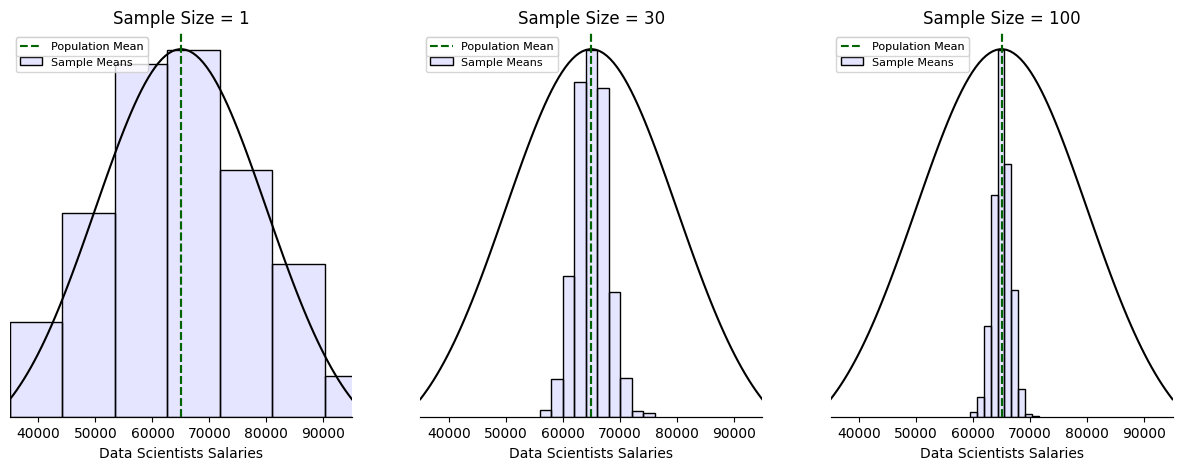

In [5]:
# Create a normal distribution
# Population parameters (mean and standard deviation)
mu = 65_000
sigma = 15_000

# Define a range of x values
x = np.linspace(mu - 2 * sigma, mu + 2 * sigma, 100)
# Calculate the probability density function (PDF)
y = stats.norm.pdf(loc=mu, scale=sigma, x=x)

# Define a grid of three subplots
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))

# Define number of replications
n_replications = 1000
# Define the sample sizes
sample_sizes = [1, 30, 100]
# Title for each subplot
titles = ["Sample Size = 1", "Sample Size = 30", "Sample Size = 100"]

# Loop over the sample sizes
for i, n in enumerate(sample_sizes):
    # Create a list to store the sample means
    sample_means = []

    # Generate n_replications samples and calculate their means
    for _ in range(n_replications):
        sample = np.random.normal(loc=mu, scale=sigma, size=n)
        sample_means.append(np.mean(sample))

    # plot a histogram of the distribution of sample means, together with the population distribution
    ax1 = sns.histplot(
        sample_means, bins=10, ax=axes[i], color="blue", label="Sample Means", alpha=0.1
    )
    ax1.set_title(titles[i])
    ax2 = ax1.twinx()
    sns.lineplot(x=x, y=y, color="black")

    # format the figures
    subaxes = [ax1, ax2]
    for ax in subaxes:
        ax.set(yticklabels=[])
        ax.set(ylabel=None)
        ax.set(xlabel="Data Scientists Salaries")
        ax.tick_params(axis="both", which="both", left=False, right=False)
        ax.spines[["right", "top", "left"]].set_visible(False)
        # vertical line at the population mean
        ax.axvline(x=mu, color="darkgreen", linestyle="--", label="Population Mean")

        # ax limits
        ax.set_xlim(mu - 2 * sigma, mu + 2 * sigma)
        # define legend
        ax.legend(loc="upper left", fontsize=8)

### Estimating population parameters
To estimate population parameters, we can use sample statistics. For example, if we want to estimate the population mean $\mu$, we can use the sample mean $\bar{x}$ as an estimate.
We can also use the sample standard deviation $s$ to estimate the population standard deviation $\sigma$.
We can also use the sample proportion $\hat{p}$ to estimate the population proportion $p$.




#### Point estimation


A **point estimate** is a single value that serves as an estimate of a population parameter. For example, the sample mean $\bar{x}$ is a point estimate of the population mean $\mu$.
The sample standard deviation $s$ is a point estimate of the population standard deviation $\sigma$.
The sample proportion $\hat{p}$ is a point estimate of the population proportion $p$.


## Summary

In this notebook you:

- Distinguished population parameters (μ, σ, p) from their sample statistics (x̄, s, p̂).
- Watched a sample statistic approach the population parameter as the sample grew (mean 63,442 at n = 100, 64,982 at n = 10,000, against a population mean of 65,000).
- Built the sampling distribution of the mean and computed its standard error, `σ/√n`.
- Applied the central limit theorem: the sampling distribution is approximately normal once n is large enough (about n > 30).

These ideas are the foundation for confidence intervals. Continue with [`2_ci_guide.ipynb`](2_ci_guide.ipynb), where the standard error `σ/√n` and the repeated-sampling logic are used to build and interpret intervals.

## References & Further Reading

- [**scipy.stats reference**](https://docs.scipy.org/doc/scipy/reference/stats.html): The `norm` distribution used to model and sample the population here.
- [**NumPy random sampling**](https://numpy.org/doc/stable/reference/random/index.html): How the repeated samples are drawn.
- [**ModernDive: Sampling and confidence intervals**](https://moderndive.com/v2/confidence-intervals.html): The sampling-distribution view of estimation, continued into confidence intervals.
